In [2]:
from pathlib import Path

import pandas as pd
import seaborn as sns

### Metadata Analysis

In [2]:
df = pd.read_csv('../PRJEB49306.SraRunTable.csv', usecols=['Run', 'Individual', 'Bases'])
df.shape

(722, 3)

In [3]:
df['Coverage'] = df['Bases'] / 133_917_231
df

,Run,Bases,Individual,Coverage
0,ERR7624587,1883252400,Plate1_A1,14.062809
1,ERR7624588,1191174300,Plate1_A10,8.894855
2,ERR7624589,1259950500,Plate1_A11,9.408427
3,ERR7624590,1004126700,Plate1_A12,7.498114
4,ERR7624591,1053252000,Plate1_A2,7.864948
...,...,...,...,...
717,ERR7625304,1057974000,Plate8_H5,7.900208
718,ERR7625305,1304414100,Plate8_H6,9.740450
719,ERR7625306,1494333300,Plate8_H7,11.158633
720,ERR7625307,1443408000,Plate8_H8,10.778359


<Axes: >

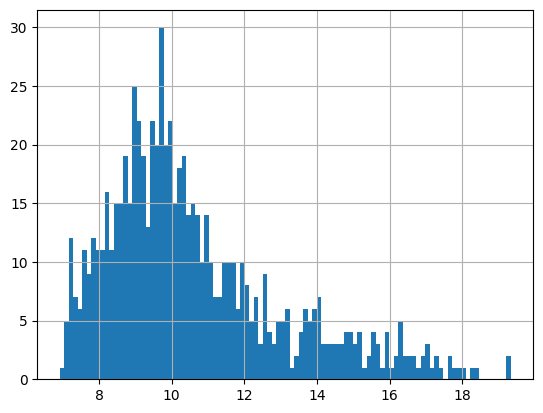

In [4]:
df['Coverage'].hist(bins=100)

In [5]:
df['Coverage'].describe()

count    722.000000
mean      10.625981
std        2.451658
min        6.923394
25%        8.945746
50%        9.966084
75%       11.756822
max       19.336527
Name: Coverage, dtype: float64

In [6]:
df['Plate'] = df['Individual'].str.split('_').str[0]
df['Plate'].value_counts()

Plate
Plate4    95
Plate3    95
Plate7    95
Plate5    95
Plate6    93
Plate8    89
Plate2    86
Plate1    74
Name: count, dtype: int64

In [7]:
df_geno = pd.read_csv('../mpipz-genotypes-raw.csv')
df_geno.head()

,Project,Sample_id,Chr_id,Start_pos,Stop_pos,Geno_1,Geno_2,CO_num,Group
0,EMS,Plate1_A1,Chr1,2398000,2406953,Col,Col/Ler,1,wt_female
1,EMS,Plate1_A1,Chr2,2292277,2292398,Col,Col/Ler,1,wt_female
2,EMS,Plate1_A1,Chr3,4805019,4815547,Col,Col/Ler,1,wt_female
3,EMS,Plate1_A2,Chr5,8656283,8656665,Col/Ler,Col,1,wt_female
4,EMS,Plate1_A4,Chr4,5739255,5739933,Col,Col/Ler,1,wt_female


In [8]:
df_geno.shape

(3490, 9)

In [9]:
df_geno = df_geno[df_geno['Project'] == 'EMS']
df_geno.shape

(2779, 9)

In [10]:
df_geno['Plate'] = df_geno['Sample_id'].str.split('_').str[0]
df_geno['Plate'].value_counts()

Plate
Plate4    527
Plate8    449
Plate3    428
Plate7    419
Plate6    275
Plate5    258
Plate2    231
Plate1    192
Name: count, dtype: int64

In [11]:
df_geno['CO_num'].value_counts()

CO_num
1    2779
Name: count, dtype: int64

In [12]:
df_agg = df_geno.groupby(['Plate', 'Group', 'Sample_id']).aggregate({'CO_num': 'sum'}).reset_index()
df_agg

,Plate,Group,Sample_id,CO_num
0,Plate1,wt_female,Plate1_A1,3
1,Plate1,wt_female,Plate1_A10,3
2,Plate1,wt_female,Plate1_A11,3
3,Plate1,wt_female,Plate1_A12,2
4,Plate1,wt_female,Plate1_A2,1
...,...,...,...,...
702,Plate8,wt_male,Plate8_H5,7
703,Plate8,wt_male,Plate8_H6,6
704,Plate8,wt_male,Plate8_H7,5
705,Plate8,wt_male,Plate8_H8,3


In [13]:
df_agg['Sample_id'].nunique()

707

In [14]:
df_joined = df_agg.merge(df.drop(columns=['Plate']), left_on='Sample_id', right_on='Individual')
df_joined.shape

(707, 8)

In [15]:
df_joined

,Plate,Group,Sample_id,CO_num,Run,Bases,Individual,Coverage
0,Plate1,wt_female,Plate1_A1,3,ERR7624587,1883252400,Plate1_A1,14.062809
1,Plate1,wt_female,Plate1_A10,3,ERR7624588,1191174300,Plate1_A10,8.894855
2,Plate1,wt_female,Plate1_A11,3,ERR7624589,1259950500,Plate1_A11,9.408427
3,Plate1,wt_female,Plate1_A12,2,ERR7624590,1004126700,Plate1_A12,7.498114
4,Plate1,wt_female,Plate1_A2,1,ERR7624591,1053252000,Plate1_A2,7.864948
...,...,...,...,...,...,...,...,...
702,Plate8,wt_male,Plate8_H5,7,ERR7625304,1057974000,Plate8_H5,7.900208
703,Plate8,wt_male,Plate8_H6,6,ERR7625305,1304414100,Plate8_H6,9.740450
704,Plate8,wt_male,Plate8_H7,5,ERR7625306,1494333300,Plate8_H7,11.158633
705,Plate8,wt_male,Plate8_H8,3,ERR7625307,1443408000,Plate8_H8,10.778359


In [16]:
df_agg2 = df_agg.groupby(['Plate', 'Group']).aggregate('size').reset_index()
df_agg2

,Plate,Group,0
0,Plate1,wt_female,71
1,Plate2,wt_female,82
2,Plate3,wt_female,39
3,Plate3,wt_male,55
4,Plate4,wt_male,95
5,Plate5,wt_female,92
6,Plate6,wt_female,91
7,Plate7,wt_female,40
8,Plate7,wt_male,55
9,Plate8,wt_male,87


In [17]:
df_agg_cov_filter = df_joined[df_joined['Coverage'].between(8, 12, inclusive='both')]
df_agg_cov_filter.shape

(477, 8)

In [18]:
df_agg2_cov_filtered = df_agg_cov_filter.groupby(['Plate', 'Group']).aggregate('size').reset_index()
df_agg2_cov_filtered

,Plate,Group,0
0,Plate1,wt_female,65
1,Plate2,wt_female,49
2,Plate3,wt_female,35
3,Plate3,wt_male,46
4,Plate4,wt_male,9
5,Plate5,wt_female,71
6,Plate6,wt_female,62
7,Plate7,wt_female,32
8,Plate7,wt_male,46
9,Plate8,wt_male,62


### Joining Kmer Counts by Plate and Sex

In [12]:
df_sra = pd.read_csv('../PRJEB49306.SraRunTable.csv', usecols=['Run', 'Individual', 'Bases'], index_col='Individual')
df_sra.shape

(722, 2)

In [13]:
df_geno = pd.read_csv('../mpipz-genotypes-raw.csv')
df_individuals = df_geno[df_geno['Project'] == 'EMS'].groupby(['Group', 'Sample_id']).aggregate({'CO_num': 'sum'}).reset_index()
df_individuals.set_index('Sample_id', inplace=True)
df_individuals

,Group,CO_num
Sample_id,,
Plate1_A1,wt_female,3
Plate1_A10,wt_female,3
Plate1_A11,wt_female,3
Plate1_A12,wt_female,2
Plate1_A2,wt_female,1
...,...,...
Plate8_H5,wt_male,7
Plate8_H6,wt_male,6
Plate8_H7,wt_male,5


In [14]:
df_individuals = df_individuals.join(df_sra, how='inner').reset_index(names='Individual')
df_individuals['Coverage'] = df_individuals['Bases'] / 133_917_231
df_individuals['Plate'] = df_individuals['Individual'].str.split('_').str[0]
df_individuals

,Individual,Group,CO_num,Run,Bases,Coverage,Plate
0,Plate1_A1,wt_female,3,ERR7624587,1883252400,14.062809,Plate1
1,Plate1_A10,wt_female,3,ERR7624588,1191174300,8.894855,Plate1
2,Plate1_A11,wt_female,3,ERR7624589,1259950500,9.408427,Plate1
3,Plate1_A12,wt_female,2,ERR7624590,1004126700,7.498114,Plate1
4,Plate1_A2,wt_female,1,ERR7624591,1053252000,7.864948,Plate1
...,...,...,...,...,...,...,...
702,Plate8_H5,wt_male,7,ERR7625304,1057974000,7.900208,Plate8
703,Plate8_H6,wt_male,6,ERR7625305,1304414100,9.740450,Plate8
704,Plate8_H7,wt_male,5,ERR7625306,1494333300,11.158633,Plate8
705,Plate8_H8,wt_male,3,ERR7625307,1443408000,10.778359,Plate8


In [22]:
df_males = df_individuals[df_individuals['Group'] == 'wt_male']
df_males['Coverage'].describe()

count    292.000000
mean      11.531887
std        2.922489
min        6.923394
25%        9.469976
50%       10.582871
75%       13.844953
max       19.336527
Name: Coverage, dtype: float64

In [23]:
df_females = df_individuals[df_individuals['Group'] == 'wt_female']
df_females['Coverage'].describe()

count    415.000000
mean      10.022547
std        1.825754
min        7.157579
25%        8.712625
50%        9.687620
75%       11.065704
max       19.226549
Name: Coverage, dtype: float64

In [24]:
import sys

sys.path.append("..")
sys.path.append("../scripts")

from scripts.join_kmer_counts_feather import join_kmer_counts

in_dir = Path("../data/mpipz/normalized-filtered-counts")
out_dir = Path("../data/mpipz/joined-counts")
out_dir.mkdir(exist_ok=True, parents=True)

for (sex, plate), df in df_individuals.groupby(["Group", "Plate"]):
    print(f"{sex=}, {plate=}, {len(df)}")

    join_kmer_counts(
        input_feather_paths=[in_dir / f"{run}.f32.feather" for run in df['Run']],
        output_feather_path=out_dir / f"{sex}_{plate}.f32.feather",
        max_jobs=16,
    )

sex='wt_female', plate='Plate1', 71
Joining 71 data frames into 16...
Joining 4 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.5.feather.tmp...
Joining 4 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.12.feather.tmp...
Joining 5 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.14.feather.tmp...
Joining 5 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.6.feather.tmp...
Joining 4 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.4.feather.tmp...
Joining 5 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.9.feather.tmp...
Joining 5 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.13.feather.tmp...
Joining 5 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.15.feather.tmp...
Joining 4 data frames into ../data/mpipz/joined-counts/wt_female_Plate1.f32.16.1.feather.tmp...
Joining 4 data frames into ../data/mpipz/joined-counts/wt_fema

### Cross-over Analysis

In [6]:
df_geno = pd.read_csv('../mpipz-genotypes-raw.csv')
df_geno = df_geno[df_geno['Project'] == 'EMS']
df_geno

,Project,Sample_id,Chr_id,Start_pos,Stop_pos,Geno_1,Geno_2,CO_num,Group
0,EMS,Plate1_A1,Chr1,2398000,2406953,Col,Col/Ler,1,wt_female
1,EMS,Plate1_A1,Chr2,2292277,2292398,Col,Col/Ler,1,wt_female
2,EMS,Plate1_A1,Chr3,4805019,4815547,Col,Col/Ler,1,wt_female
3,EMS,Plate1_A2,Chr5,8656283,8656665,Col/Ler,Col,1,wt_female
4,EMS,Plate1_A4,Chr4,5739255,5739933,Col,Col/Ler,1,wt_female
...,...,...,...,...,...,...,...,...,...
2774,EMS,Plate8_H10,Chr4,16691488,16692715,Col/Ler,Col,1,wt_male
2775,EMS,Plate8_H10,Chr5,9259227,9259437,Col/Ler,Col,1,wt_male
2776,EMS,Plate8_H10,Chr5,15864272,15864369,Col,Col/Ler,1,wt_male
2777,EMS,Plate8_H11,Chr1,21399022,21399084,Col/Ler,Col,1,wt_male


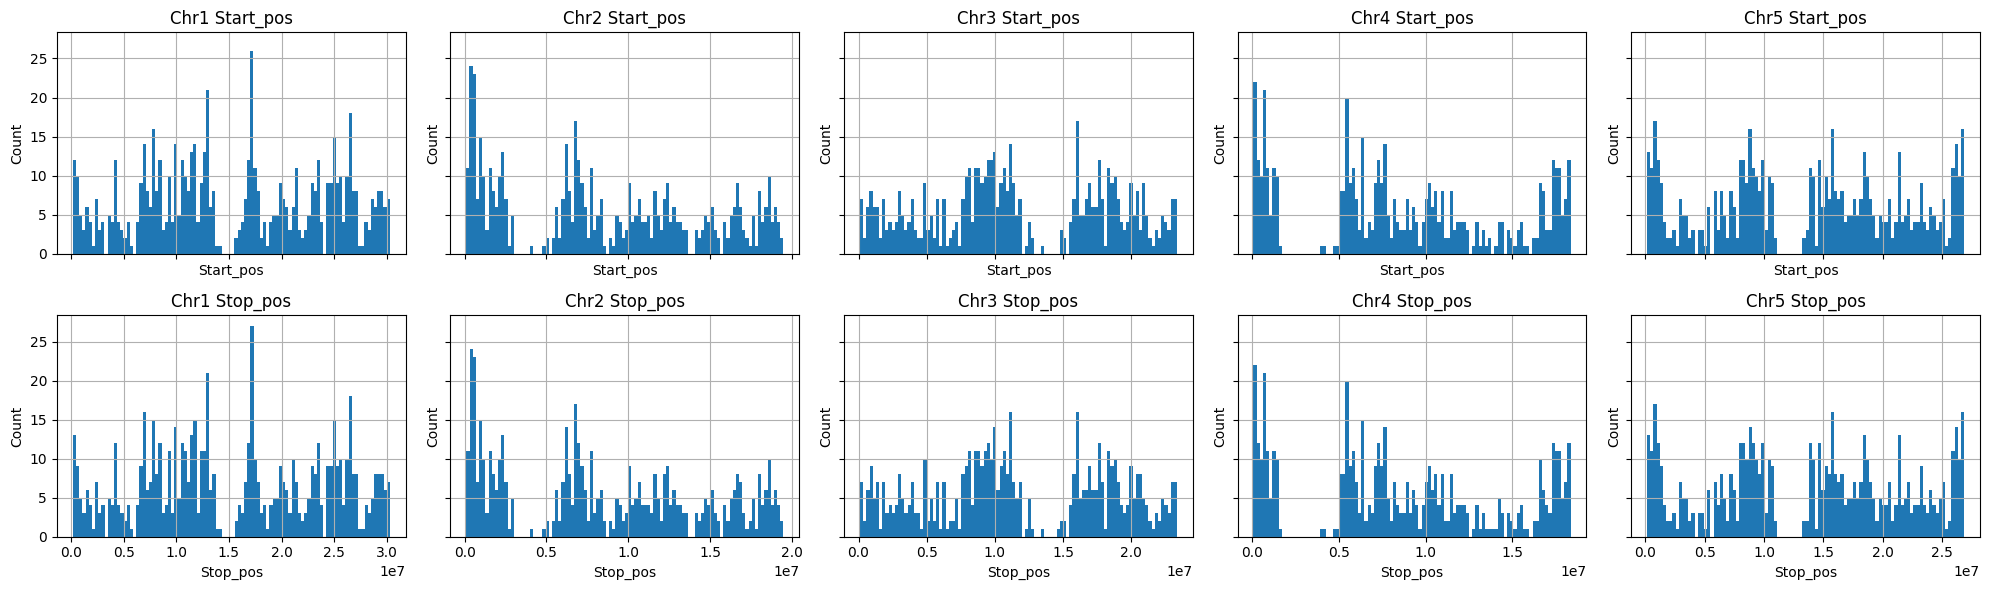

In [7]:
import matplotlib.pyplot as plt

chromosomes = [f"Chr{i}" for i in range(1, 6)]
fig, axes = plt.subplots(2, len(chromosomes), figsize=(20, 6), sharey='all', sharex='col')

for idx, chr_name in enumerate(chromosomes):
    df_chr = df_geno[df_geno['Chr_id'] == chr_name]
    # Start_pos
    ax_start = axes[0, idx]
    df_chr['Start_pos'].hist(bins=100, ax=ax_start)
    ax_start.set_title(f"{chr_name} Start_pos")
    ax_start.set_xlabel("Start_pos")
    ax_start.set_ylabel("Count")
    # Stop_pos
    ax_stop = axes[1, idx]
    df_chr['Stop_pos'].hist(bins=100, ax=ax_stop)
    ax_stop.set_title(f"{chr_name} Stop_pos")
    ax_stop.set_xlabel("Stop_pos")
    ax_stop.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [8]:
# Define centromere regions for each chromosome (example coordinates, adjust as needed)
centromere_regions = {
    'Chr1': (14_000_000, 16_000_000),
    'Chr2': (3_000_000, 5_000_000),
    'Chr3': (13_000_000, 15_000_000),
    'Chr4': (2_500_000, 5_000_000),
    'Chr5': (11_000_000, 13_000_000),
}

    # Prepare a result dataframe
results = []
for sample_id, group in df_geno.groupby('Sample_id'):
    centromere_genotypes = {}
    for chr_id, (start, stop) in centromere_regions.items():
        # Select cross-overs for this sample and chromosome
        df_chr = group[group['Chr_id'] == chr_id]
        # Check if any cross-over overlaps the centromere region
        overlap = df_chr[
            (df_chr['Start_pos'] <= stop) & (df_chr['Stop_pos'] >= start)
        ]
        if overlap.empty:
            # No cross-over in centromere region: infer genotype from flanking markers
            # Use the closest marker before and after the centromere
            before = df_chr[df_chr['Stop_pos'] < start]
            after = df_chr[df_chr['Start_pos'] > stop]
            # Sort by position to ensure correct flanking markers
            before_sorted = before.sort_values('Stop_pos')
            after_sorted = after.sort_values('Start_pos')
            geno_before = before_sorted.iloc[-1]['Geno_2'] if not before_sorted.empty else None
            geno_after = after_sorted.iloc[0]['Geno_1'] if not after_sorted.empty else None
            # Assign genotype: if both flanking genotypes agree, use that, else 'Unknown'
            if geno_before and geno_after and geno_before == geno_after:
                centromere_genotypes[chr_id] = geno_before
            elif not geno_before and geno_after:
                centromere_genotypes[chr_id] = geno_after
            elif not geno_after and geno_before:
                centromere_genotypes[chr_id] = geno_before
            else:
                centromere_genotypes[chr_id] = 'Unknown'
        else:
            # Cross-over in centromere region: cannot assign
            centromere_genotypes[chr_id] = 'Recombinant'

    results.append({'Sample_id': sample_id, **centromere_genotypes})

df_centromere_genotypes = pd.DataFrame(results)
df_centromere_genotypes.set_index('Sample_id', inplace=True)
df_centromere_genotypes

,Chr1,Chr2,Chr3,Chr4,Chr5
Sample_id,,,,,
Plate1_A1,Col/Ler,Col/Ler,Col/Ler,Unknown,Unknown
Plate1_A10,Col,Unknown,Col/Ler,Col/Ler,Unknown
Plate1_A11,Col,Unknown,Col,Col,Unknown
Plate1_A12,Unknown,Col/Ler,Col,Unknown,Unknown
Plate1_A2,Unknown,Unknown,Unknown,Unknown,Col
...,...,...,...,...,...
Plate8_H5,Col/Ler,Unknown,Col,Col/Ler,Col
Plate8_H6,Col/Ler,Col/Ler,Col/Ler,Col,Col/Ler
Plate8_H7,Col/Ler,Unknown,Col/Ler,Unknown,Col


In [9]:
pd.Series(df_centromere_genotypes.values.flatten()).value_counts()

Unknown        1322
Col            1101
Col/Ler        1097
Recombinant      15
Name: count, dtype: int64

In [19]:
df_no_unknown = df_centromere_genotypes[
    (~df_centromere_genotypes.isin(['Unknown', 'Recombinant'])).all(axis=1)
]
df_no_unknown

,Chr1,Chr2,Chr3,Chr4,Chr5
Sample_id,,,,,
Plate1_B2,Col/Ler,Col,Col/Ler,Col,Col/Ler
Plate1_C2,Col/Ler,Col,Col/Ler,Col/Ler,Col
Plate1_C8,Col/Ler,Col/Ler,Col,Col,Col/Ler
Plate1_G9,Col/Ler,Col,Col,Col,Col
Plate2_E9,Col/Ler,Col/Ler,Col/Ler,Col/Ler,Col/Ler
...,...,...,...,...,...
Plate8_F7,Col,Col,Col,Col,Col/Ler
Plate8_G10,Col,Col/Ler,Col/Ler,Col,Col
Plate8_G7,Col,Col/Ler,Col/Ler,Col/Ler,Col


In [15]:
df_filtered_individuals = df_individuals[df_individuals['Individual'].isin(df_no_unknown.index)]
df_filtered_individuals

,Individual,Group,CO_num,Run,Bases,Coverage,Plate
13,Plate1_B2,wt_female,5,ERR7624601,1197474900,8.941903,Plate1
23,Plate1_C2,wt_female,5,ERR7624612,1296780000,9.683444,Plate1
26,Plate1_C8,wt_female,5,ERR7624615,1202347500,8.978288,Plate1
67,Plate1_G9,wt_female,5,ERR7624657,1520593200,11.354724,Plate1
123,Plate2_E9,wt_female,5,ERR7624717,1155893100,8.631399,Plate2
...,...,...,...,...,...,...,...
684,Plate8_F7,wt_male,6,ERR7625285,1241653200,9.271796,Plate8
687,Plate8_G10,wt_male,7,ERR7625288,1214691600,9.070465,Plate8
694,Plate8_G7,wt_male,6,ERR7625296,1210840200,9.041706,Plate8
703,Plate8_H6,wt_male,6,ERR7625305,1304414100,9.740450,Plate8


In [11]:
df_filtered_individuals['Group'].value_counts()

Group
wt_male      62
wt_female    18
Name: count, dtype: int64

In [12]:
import sys

sys.path.append("..")
sys.path.append("../scripts")

from scripts.join_parts import join_parts

in_dir = Path("../data/mpipz/joined-counts")
out_dir = Path("../data/mpipz/filtered-joined-counts-80")

out_dir.mkdir(exist_ok=True, parents=True)

for (sex, plate), df in df_filtered_individuals.groupby(["Group", "Plate"]):
    print(f"{sex=}, {plate=}, {len(df)}")

    def transform_part(df_part: pd.DataFrame) -> pd.DataFrame:
        df_part.drop(columns=df_part.columns.difference(df['Run'].to_list()), inplace=True)
        assert len(df_part.columns) == df.shape[0]
        return df_part

    output_path = out_dir / f"{sex}_{plate}.feather"

    if output_path.exists():
        print(f"Skipping existing {output_path}")
        continue

    join_parts(
        input_feather_paths=sorted(in_dir.glob(f"{sex}_{plate}.f32.part.*.feather")),
        output_feather_path=output_path,
        transform_part=transform_part,
    )


sex='wt_female', plate='Plate1', 4
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate1.feather
sex='wt_female', plate='Plate2', 1
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate2.feather
sex='wt_female', plate='Plate3', 6
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate3.feather
sex='wt_female', plate='Plate5', 2
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate5.feather
sex='wt_female', plate='Plate6', 4
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate6.feather
sex='wt_female', plate='Plate7', 1
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_female_Plate7.feather
sex='wt_male', plate='Plate3', 10
Skipping existing ../data/mpipz/filtered-joined-counts-80/wt_male_Plate3.feather
sex='wt_male', plate='Plate4', 26
../data/mpipz/joined-counts/wt_male_Plate4.f32.part.1.feather: (11035709, 95)
../data/mpipz/joined-counts/wt_male_Plate4.f32.part.1.feather aft

In [13]:
for path in sorted(out_dir.glob("*.feather")):
    df = pd.read_feather(path)
    print(f"{path}: {df.shape}")
    df.fillna(0, inplace=True)
    df = df[df.sum(axis=1) > 0]
    print(f"After filtering zero-rows: {df.shape}")
    df.to_feather(path.with_stem(path.stem + ".reduced"))

../data/mpipz/filtered-joined-counts-80/wt_female_Plate1.feather: (102168937, 4)
After filtering zero-rows: (36744559, 4)
../data/mpipz/filtered-joined-counts-80/wt_female_Plate2.feather: (107944908, 1)
After filtering zero-rows: (14733616, 1)
../data/mpipz/filtered-joined-counts-80/wt_female_Plate3.feather: (91092093, 6)
After filtering zero-rows: (47360444, 6)
../data/mpipz/filtered-joined-counts-80/wt_female_Plate5.feather: (112119115, 2)
After filtering zero-rows: (31522971, 2)
../data/mpipz/filtered-joined-counts-80/wt_female_Plate6.feather: (102597701, 4)
After filtering zero-rows: (34299910, 4)
../data/mpipz/filtered-joined-counts-80/wt_female_Plate7.feather: (96439689, 1)
After filtering zero-rows: (16236176, 1)
../data/mpipz/filtered-joined-counts-80/wt_male_Plate3.feather: (97572063, 10)
After filtering zero-rows: (57240929, 10)
../data/mpipz/filtered-joined-counts-80/wt_male_Plate4.feather: (88249141, 26)
After filtering zero-rows: (63146453, 26)
../data/mpipz/filtered-joine

In [3]:
import sys

sys.path.append("..")
sys.path.append("../scripts")

out_dir = Path("../data/mpipz/filtered-joined-counts-80")

from scripts.join_kmer_counts_feather import join_kmer_counts

join_kmer_counts(
    input_feather_paths=sorted(out_dir.glob("*.reduced.feather")),
    output_feather_path=out_dir / "filter-joint-counts-80.feather",
    max_jobs=4,
    partition_threshold=int(2.5 * 1024 * 1024 * 1024)
)

Joining 10 data frames into 4...
Joining 2 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.4.1.feather.tmp...
Joining 3 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.4.0.feather.tmp...
Joining 2 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.4.2.feather.tmp...
Joining 3 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.4.3.feather.tmp...
Splitting files into parts...
Joining part 1/4...
Joining 4 data frames into 2...
Joining 2 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.part.1.2.1.feather.tmp...
Joining 2 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.part.1.2.0.feather.tmp...
Joining 2 data frames into ../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.part.1.feather...
Joining part 2/4...
Joining 4 data frames into 2...
Joining 2 data frames into ../data/mpipz/filtered-joined-

In [ ]:

from typing import Union
import torch


def correlate_kmers_with_genotypes_torch(
    df_meta: pd.DataFrame,
    df_g: pd.DataFrame,
    kmer_count_feather_path: Union[Path, str],
) -> pd.DataFrame:
    df_g = df_g.map(lambda x: {"Col": 0, "Col/Ler": 1}.get(x, x))

    # Load kmer counts
    df = pd.read_feather(kmer_count_feather_path)
    df.rename(columns=lambda run: df_meta.loc[run, "Individual"], inplace=True)
    df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
    df.fillna(0, inplace=True)
    df = df[df.sum(axis=1) > 0]

    df_g = df_g[df_g.index.isin(df.columns)]

    df_t = df.transpose()
    df_t = df_t.reindex(df_g.index)

    assert df_g.index.equals(df_t.index)

    X = torch.tensor(df_t.values, dtype=torch.float32)  # shape: [samples, kmers]
    corr_df = pd.DataFrame(index=df_t.columns)

    for chr in df_g.columns:
        y = torch.tensor(df_g[chr].values, dtype=torch.float32)  # shape: [samples]

        X_centered = X - X.mean(dim=0)
        y_centered = y - y.mean()

        numerator = (X_centered * y_centered.unsqueeze(1)).sum(dim=0)
        denominator = torch.sqrt((X_centered**2).sum(dim=0) * (y_centered**2).sum())
        corr = numerator / denominator
        corr_df[chr] = corr.cpu().numpy().astype("float32")

    return corr_df


In [20]:

for path in sorted(out_dir.glob("filter-joint-counts-80.part.*.feather")):
    df_corr = correlate_kmers_with_genotypes_torch(
        df_meta=df_filtered_individuals.set_index('Run'),
        df_g=df_no_unknown,
        kmer_count_feather_path=path,
    )

    print(df_corr.shape)

    df_corr.to_feather(path.with_stem(path.stem + ".corr"))

(26522529, 5)
(26525927, 5)
(26527382, 5)
(26526105, 5)


In [21]:
df_corr_joined = pd.concat(
    [pd.read_feather(path) for path in sorted(out_dir.glob("filter-joint-counts-80.part.*.corr.feather"))]
)

df_corr_joined.to_feather(out_dir / "filter-joint-counts-80.corr.feather")

print(df_corr_joined.shape)

(106101943, 5)


In [22]:
df_corr = pd.read_feather("../data/mpipz/filtered-joined-counts-80/filter-joint-counts-80.corr.feather")
print(df_corr.shape)
df_corr.head()

(106101943, 5)


,Chr1,Chr2,Chr3,Chr4,Chr5
kmer,,,,,
AAAAAAAAAAAAAAAAAAAAATC,-0.174082,-0.075711,0.105406,0.026602,-0.047106
AAAAAAAAAAAAAAAAAAAACCA,-0.146471,-0.215287,0.139780,0.073122,-0.016076
AAAAAAAAAAAAAAAAAAAACCC,0.032433,-0.094473,-0.380381,0.023547,-0.016439
AAAAAAAAAAAAAAAAAAAACGA,-0.082242,0.060063,-0.204121,0.096083,-0.191027
AAAAAAAAAAAAAAAAAAAACGG,-0.217508,0.152298,0.154545,0.133260,0.011381


<Axes: >

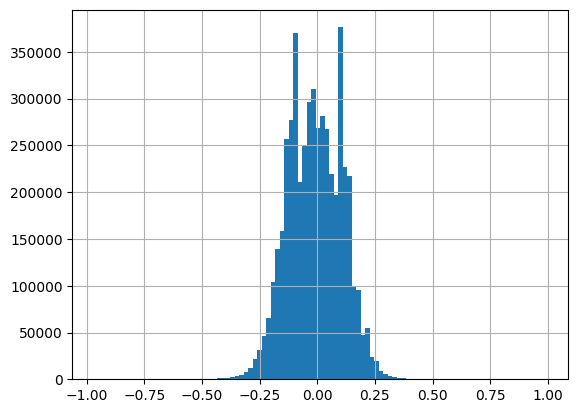

In [24]:
pd.Series(df_corr.sample(1_000_000).values.flatten()).hist(bins=100)

In [25]:
df1 = df_corr[df_corr.abs().max(axis=1) >= 0.25]
df1.shape

(11449143, 5)

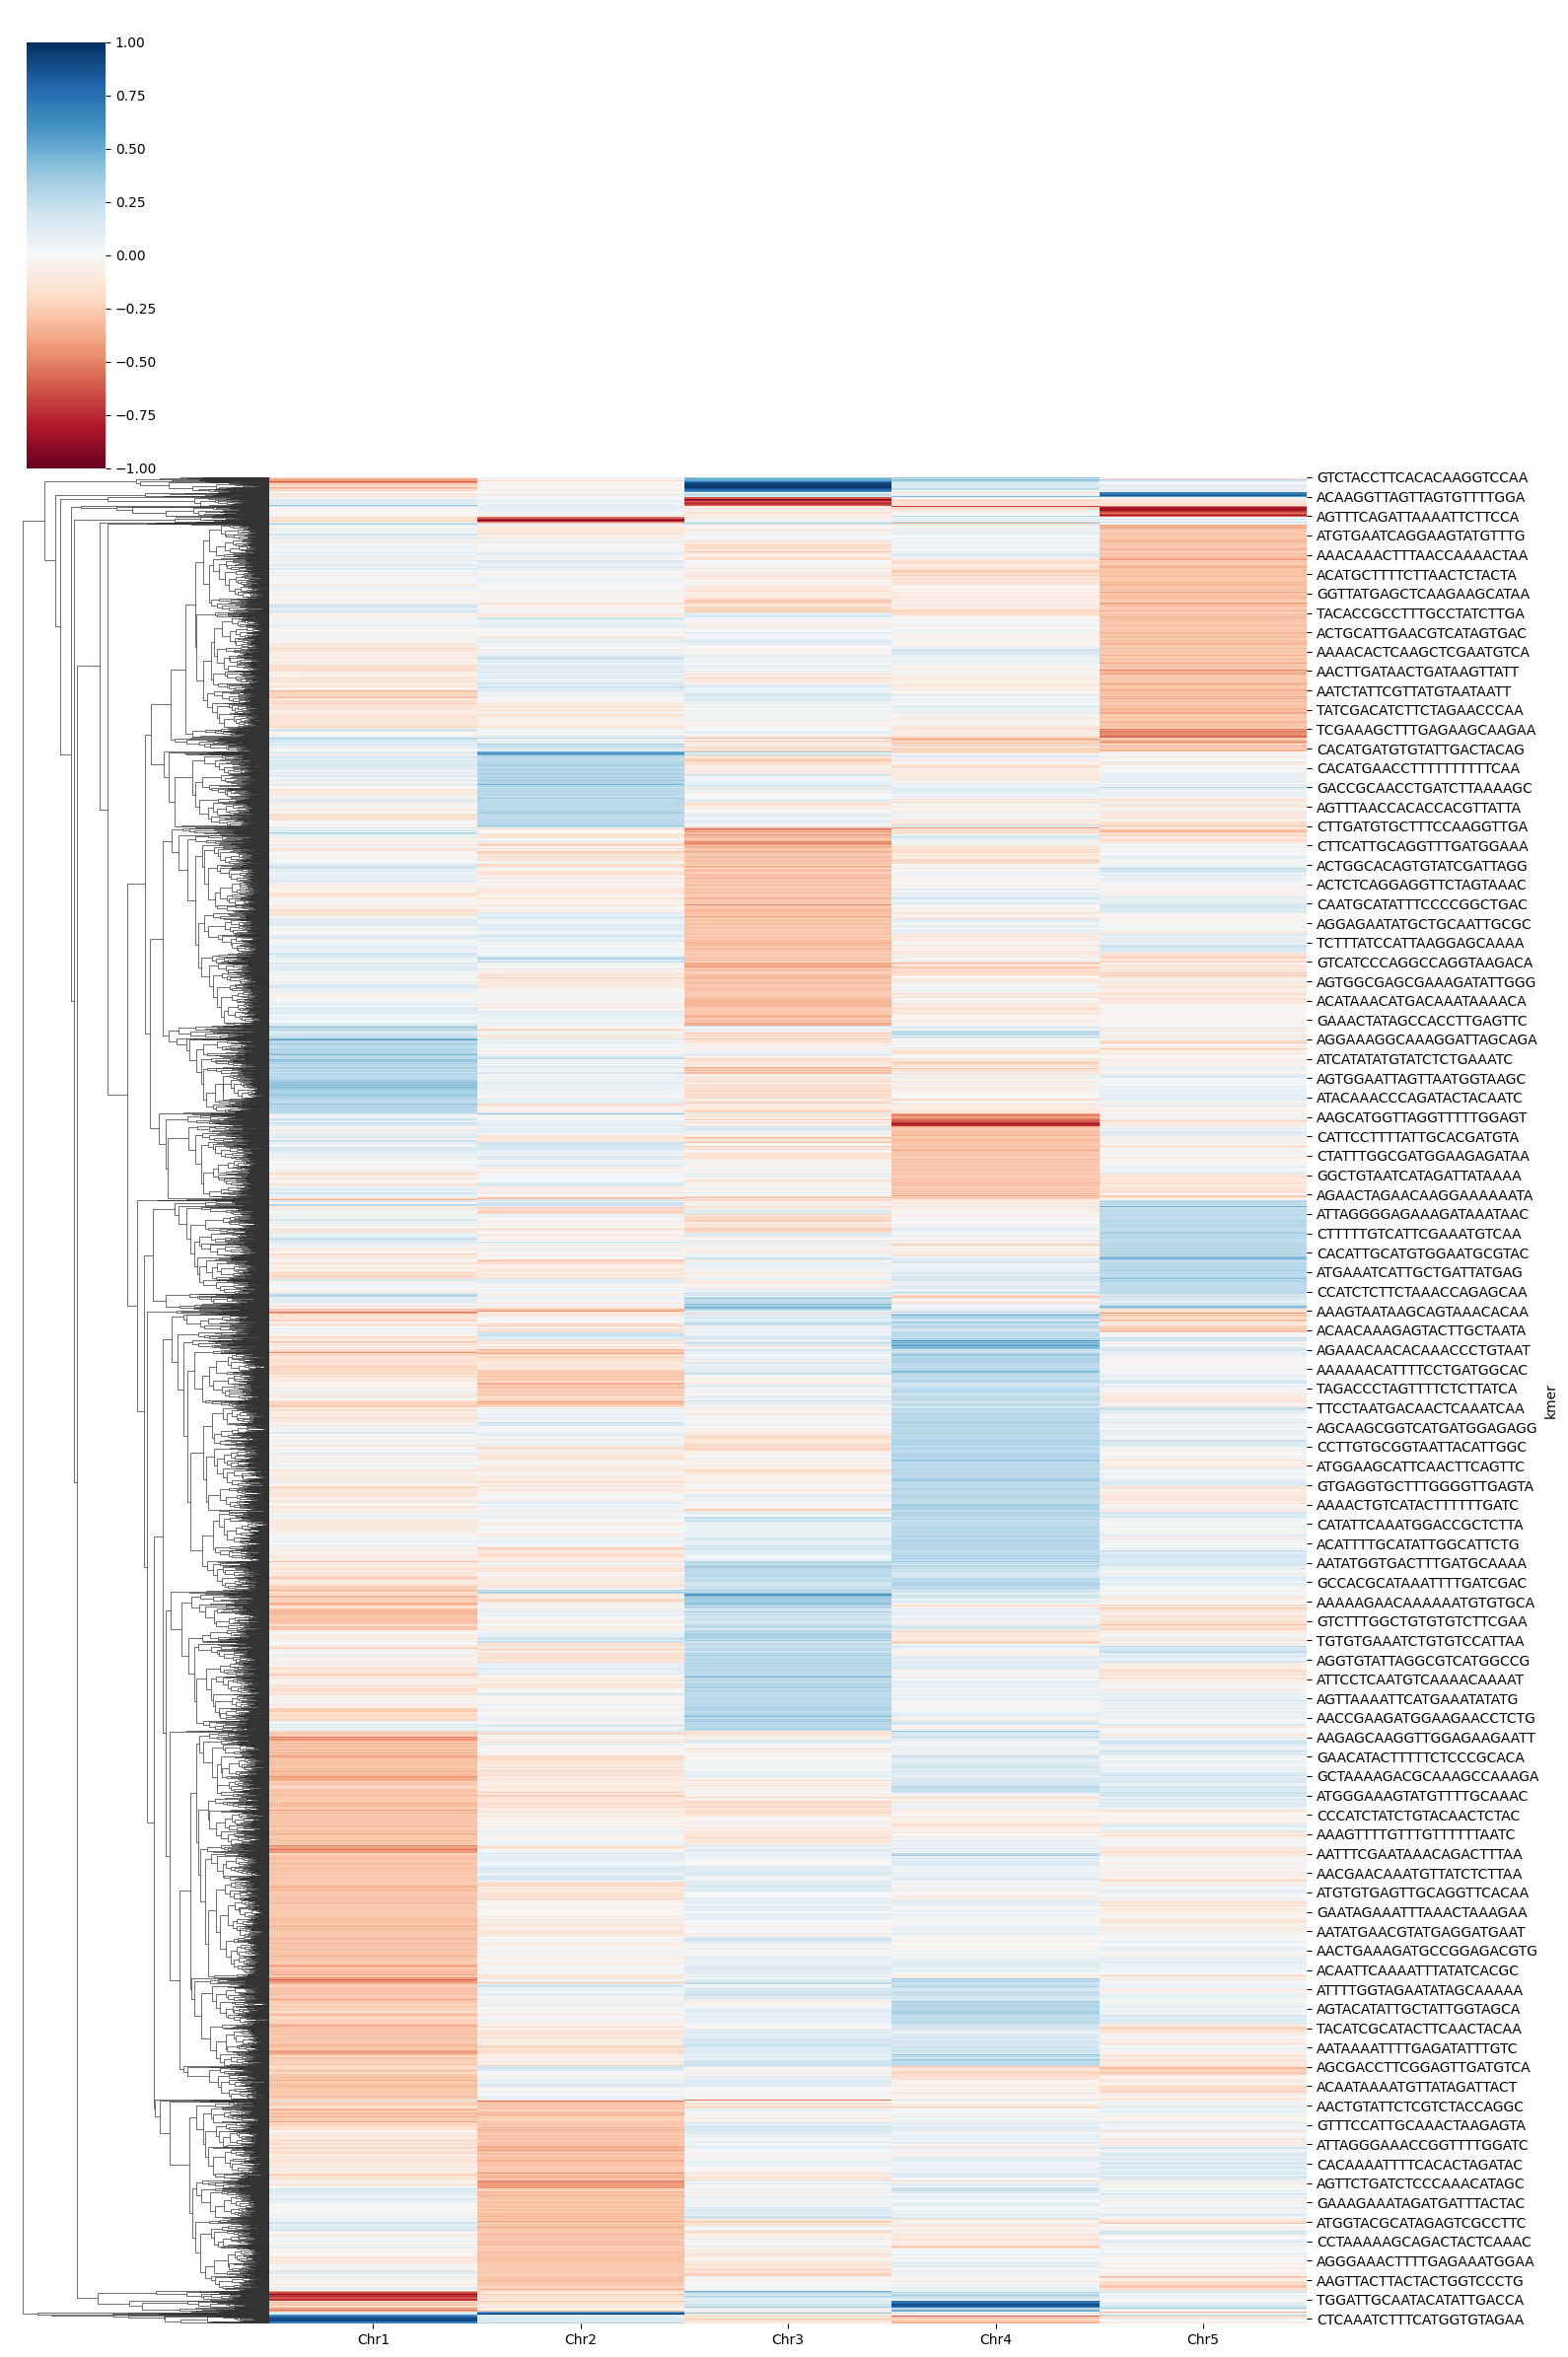

In [26]:
sns.clustermap(
    df1.sample(8192).reindex(sorted(df1.columns), axis=1),
    col_cluster=False,
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)

In [27]:
df2 = df_corr[df_corr.abs().max(axis=1) >= 0.5]
df2.shape

(632667, 5)

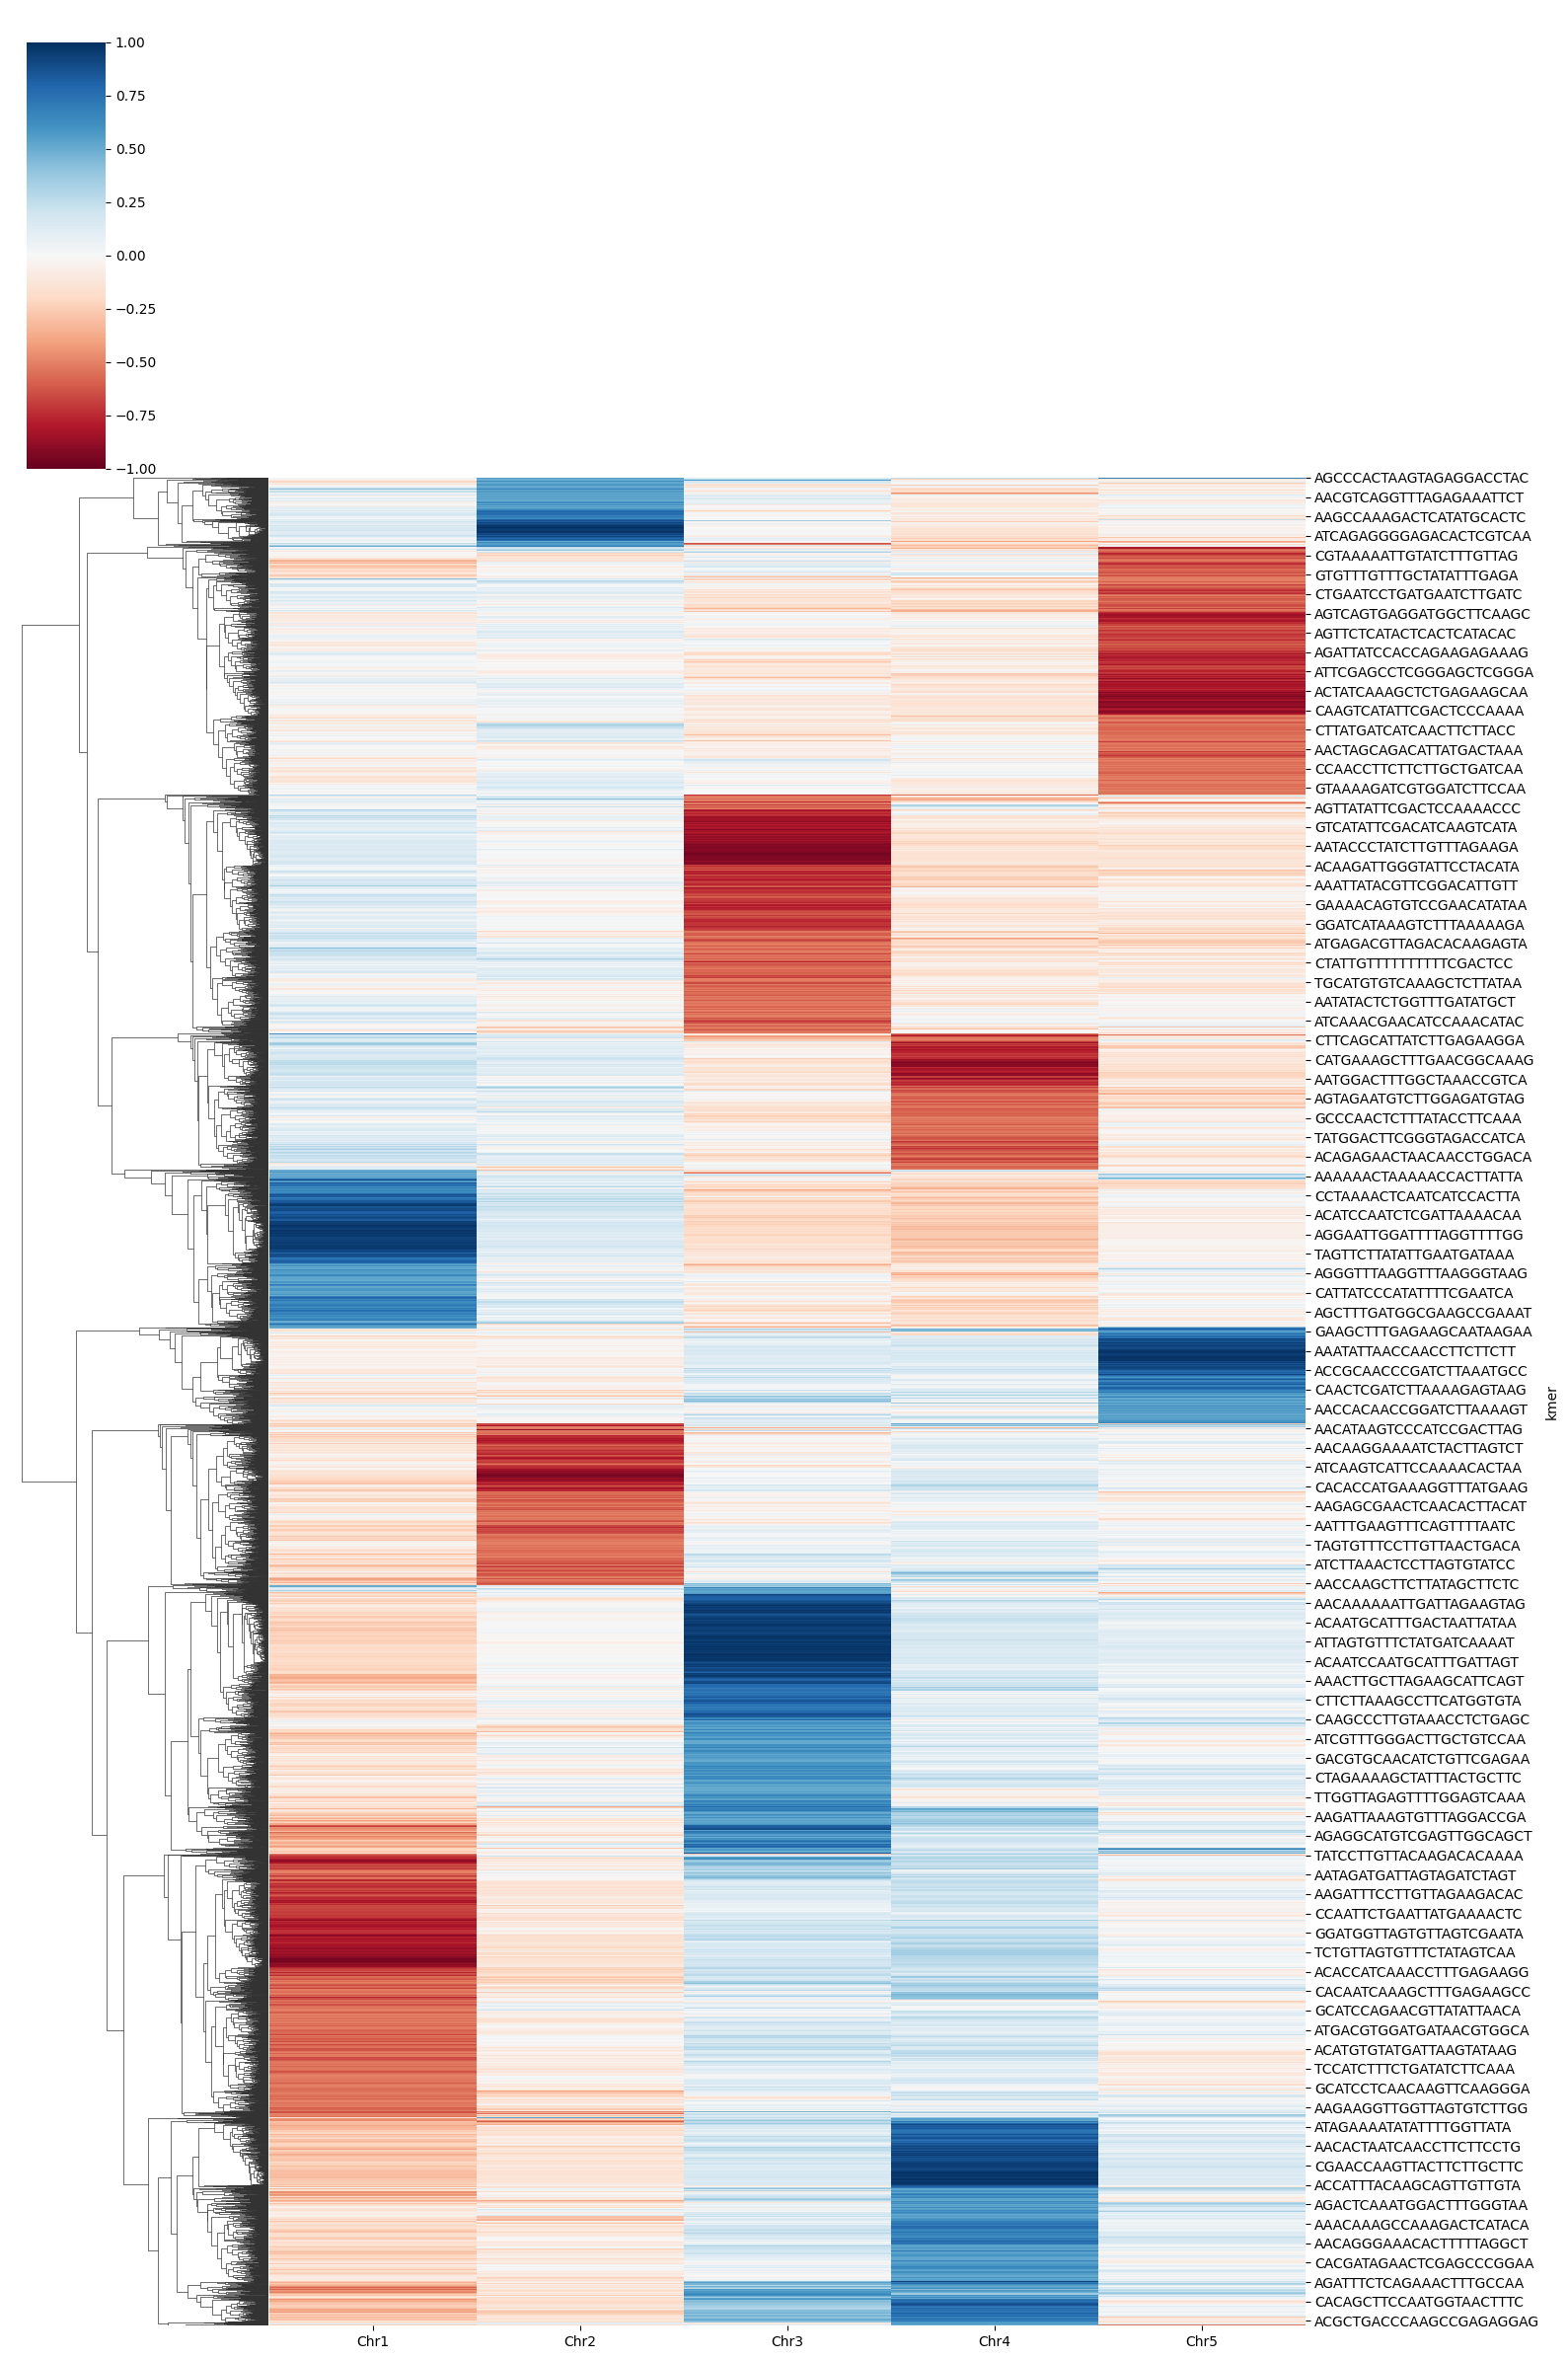

In [28]:
sns.clustermap(
    df2.sample(8192).reindex(sorted(df2.columns), axis=1),
    col_cluster=False,
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)

In [29]:
df3 = df_corr[(df_corr.max(axis=1) >= 0.5) & (df_corr.min(axis=1) <= -0.5)]
df3.shape

(6073, 5)

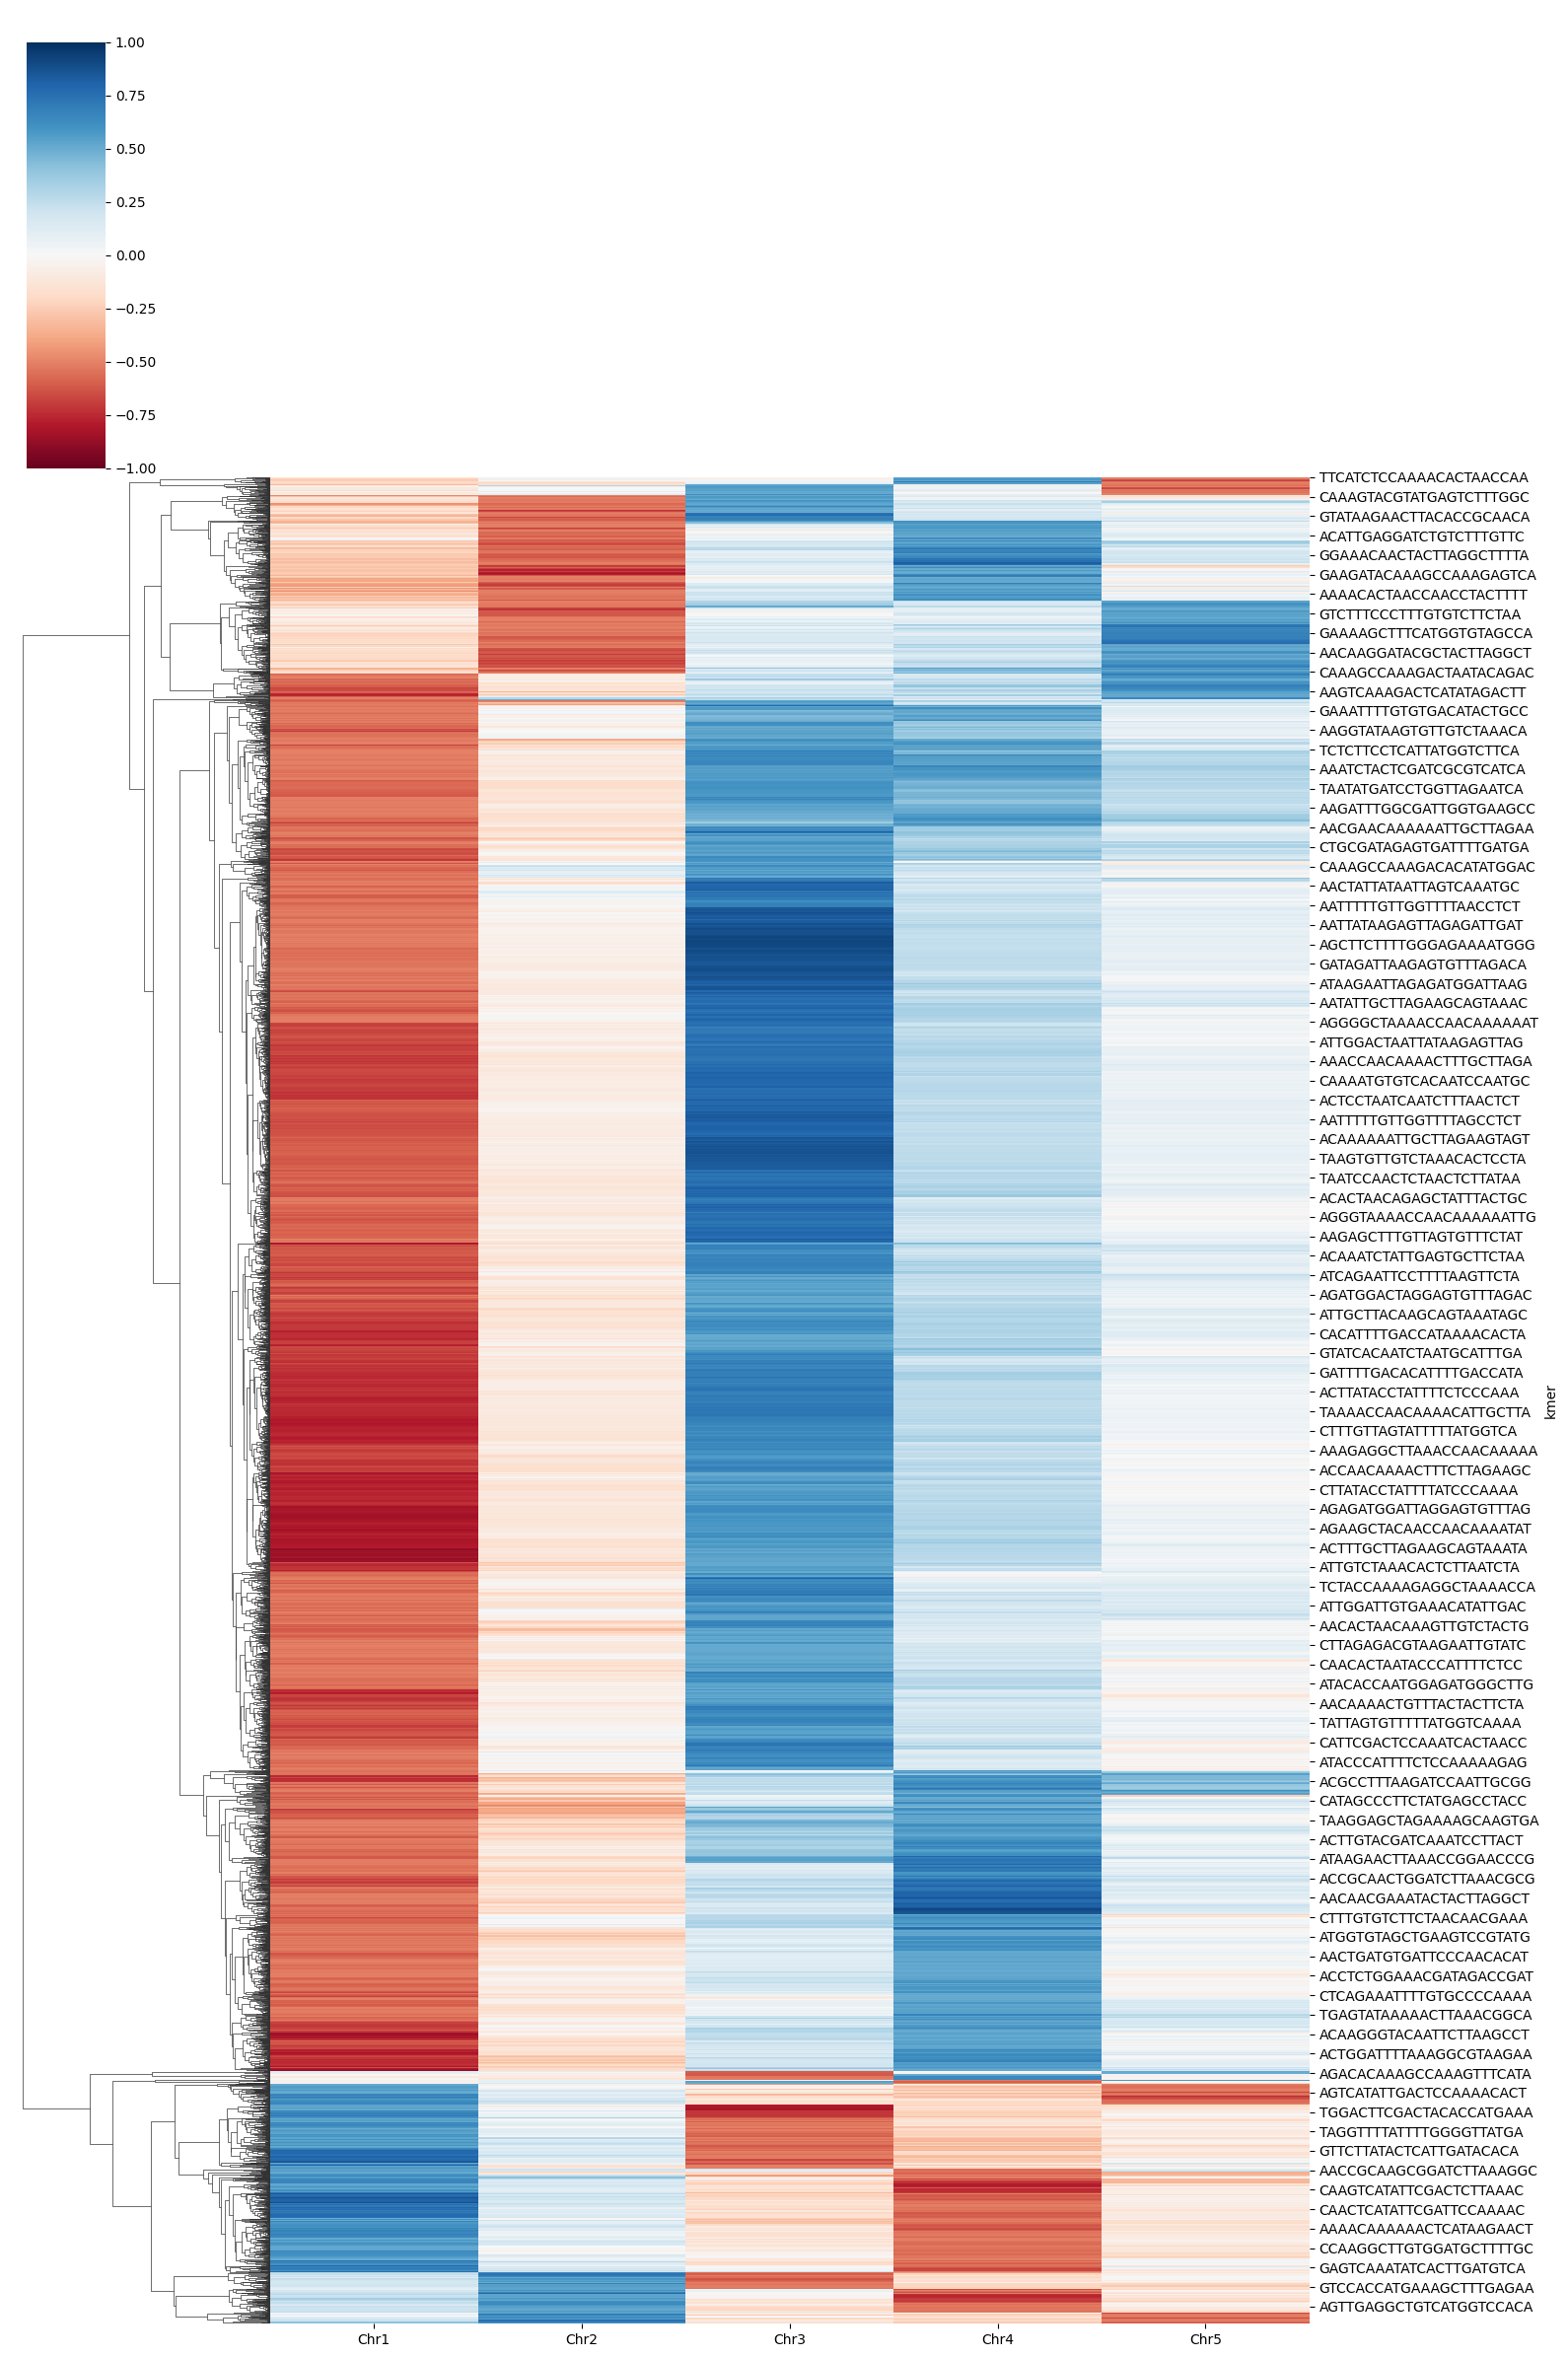

In [30]:
sns.clustermap(
    df3.reindex(sorted(df3.columns), axis=1),
    col_cluster=False,
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)